# Notebook to train the model for gender classification

### 1. Import

In [40]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from PIL import Image


from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import precision_score, recall_score
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
import sys
sys.path.append('..')
from shoppingassistant.helper_functions import load_images_and_labels, split_train_val

### 2. Load data and images

In [41]:
X, y, categories = load_images_and_labels(
        target_column='index_group_name',
        num_images=600 # None = all images, or set to 100 for testing
    )

num_classes = len(categories)

Using 600 images
Categories (3): ['Baby/Children', 'Ladieswear', 'Menswear']
 Loaded 600 images
 X shape: (600, 256, 256, 3)
 y shape: (600,)


### 3. One Hot encode labels

In [42]:
y_encoded = to_categorical(y, num_classes = num_classes)
print(f"Labels shape after encoding: {y_encoded.shape}")

Labels shape after encoding: (600, 3)


### 4. Split data for training and testing

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2,
                                             stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2,
                                             stratify=y_train, random_state=42)

print(f"Training data size: {X_train.shape} {y_train.shape}")
print(f"Validation data size: {X_val.shape} {y_val.shape}")
print(f"Test data size: {X_test.shape} {y_test.shape}")

Training data size: (384, 256, 256, 3) (384, 3)
Validation data size: (96, 256, 256, 3) (96, 3)
Test data size: (120, 256, 256, 3) (120, 3)


### 5. Compute class weights for inbalanced data

In [44]:
y_int = np.argmax(y_encoded, axis=1)  # Converts to integers: 0, 1, 2

classes = np.unique(y_int)
cw = class_weight.compute_class_weight(class_weight='balanced',
                                        classes=classes,
                                        y=y_int)
class_weights = dict(zip(classes, cw))
print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(1.2738853503184713), np.int64(1): np.float64(0.6666666666666666), np.int64(2): np.float64(1.3986013986013985)}


### 6. Build and compile model using pre-trained model

In [45]:
# Build model
data_augmentation = Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.15),
            layers.RandomZoom(0.1),
            layers.RandomTranslation(0.05, 0.05),
            layers.RandomContrast(0.1),
        ])


base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape = (256,256,3)
)
base_model.trainable = False   # Freeze for first stage
input_shape = (256,256,3)
inputs = layers.Input(shape=input_shape)
x = data_augmentation(inputs)
x = x * 255.0       # scale back to 0-255
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)


outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model built and compiled")
model.summary()


Model built and compiled


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_4 (Multiply)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 8, 8, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,735,090 (44.77 MB)

 Trainable params: 951,555 (3.63 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

### Fine Tuning last layer

In [46]:
'''
for layer in base_model.layers:
    if layer.name.startswith("top_conv"):
        layer.trainable = True

# ALWAYS keep BatchNorm layers frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Recompile with a very small learning rate
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(1e-5),  # small LR for fine-tuning
    metrics=['accuracy']
)

print("Model ready for fine-tuning:")
model.summary()
'''

'\nfor layer in base_model.layers:\n    if layer.name.startswith("top_conv"):\n        layer.trainable = True\n\n# ALWAYS keep BatchNorm layers frozen\nfor layer in base_model.layers:\n    if isinstance(layer, layers.BatchNormalization):\n        layer.trainable = False\n\n# Recompile with a very small learning rate\nmodel.compile(\n    loss=\'categorical_crossentropy\',\n    optimizer=Adam(1e-5),  # small LR for fine-tuning\n    metrics=[\'accuracy\']\n)\n\nprint("Model ready for fine-tuning:")\nmodel.summary()\n'

### 7. Train model

In [ ]:
NOTEBOOK_DIR = Path().resolve().parent  # -> notebooks/my_notebook
MODELS_DIR = NOTEBOOK_DIR/"models"
MODEL_PATH = MODELS_DIR/"gender_classifier.keras"

epochs = 60

callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
        #ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=5),
        ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor="val_accuracy", mode="max")
    ]

print("🚀 Training started...")
history = model.fit(X_train, y_train,
                validation_data=(X_val,y_val),
                epochs=epochs,
                class_weight=class_weights,
                batch_size=32,
                callbacks=callbacks)

print("🎉 Training complete!")
print(f"Model saved at {MODEL_PATH}")


🚀 Training started...
Epoch 1/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.5495 - loss: 0.9828 - val_accuracy: 0.6250 - val_loss: 0.8746 - learning_rate: 0.0010
Epoch 2/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6745 - loss: 0.7655 - val_accuracy: 0.6458 - val_loss: 0.7555 - learning_rate: 0.0010
Epoch 3/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7057 - loss: 0.7030 - val_accuracy: 0.6979 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 4/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7396 - loss: 0.5766 - val_accuracy: 0.6562 - val_loss: 0.7786 - learning_rate: 0.0010
Epoch 5/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7865 - loss: 0.5287 - val_accuracy: 0.6667 - val_loss: 0.8068 - learning_rate: 0.0010
Epoch 6/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.8438 - loss: 0.4153 - val_accuracy: 0.7292 - val_loss: 0.7300 - learning_rate: 0.0010
Epoch 7/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8333 - loss: 0

### 8. Evaluate model

In [48]:
loss, accuracy = model.evaluate(X_val, y_val)

# Get predictions
y_pred = model.predict(X_test)
y_true = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

precision = precision_score(y_true, y_pred_labels, average='macro')
recall = recall_score(y_true, y_pred_labels, average='macro')

print(f"{'='* 100}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"{'='* 100}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 808ms/step - accuracy: 0.8021 - loss: 0.6652
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x137afae60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step  
Accuracy: 80.21%
precision: 0.7012558535547041
recall: 0.6878754171301447


### 9. Plot accuracy and loss

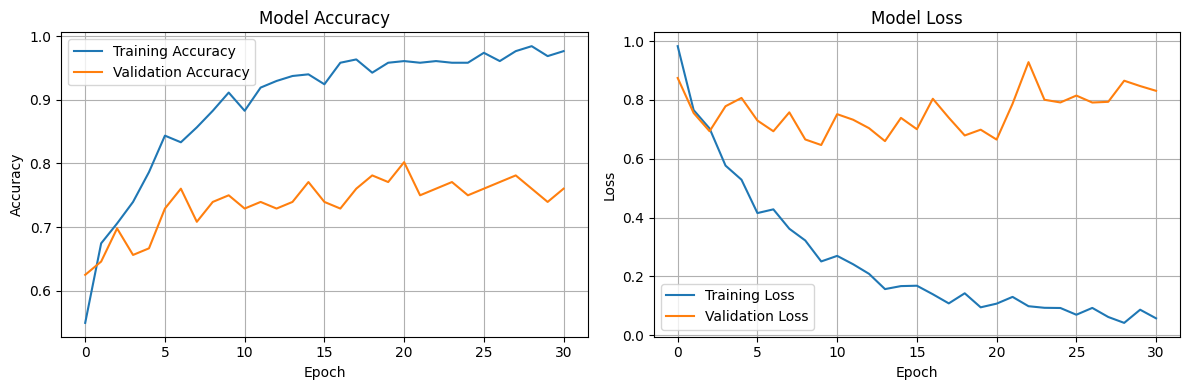

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 10. Model prediction from our data

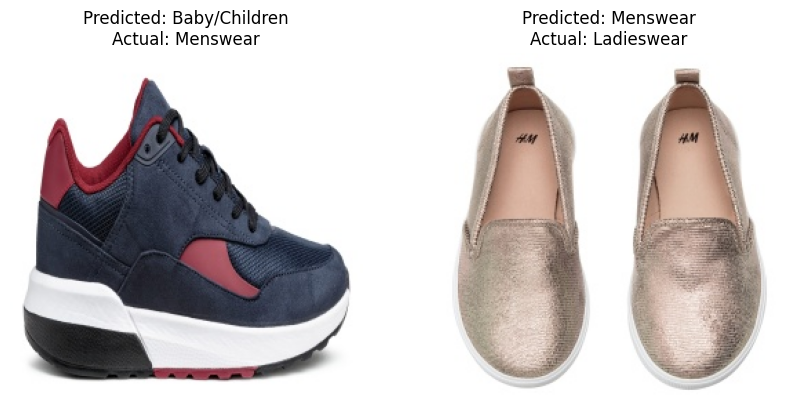

In [50]:
test_images = X_test[0:2]   # shape (2, H, W, C)
test_labels = y_test[0:2]   # corresponding labels

predictions = model.predict(test_images, verbose=0)

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, ax in enumerate(axes):
    pred_idx = np.argmax(predictions[i])
    pred_gender= categories[pred_idx]

    actual_idx = np.argmax(test_labels[i])
    actual_gender = categories[actual_idx]

    ax.imshow(test_images[i])
    ax.set_title(f"Predicted: {pred_gender}\nActual: {actual_gender}")
    ax.axis('off')

plt.show()

### 11. Model prediction from random image

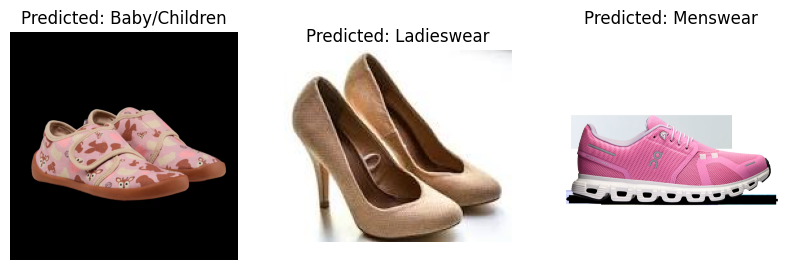

In [51]:
test_images_raw = [NOTEBOOK_DIR/'raw_data/test_images/kids.jpg',
                   NOTEBOOK_DIR/'raw_data/test_images/download2.jpeg',
                   NOTEBOOK_DIR/'raw_data/test_images/shoes_1.jpg']
display_images = []
test_images = []

from shoppingassistant.helper_functions import preprocess_single_image

# Preprocess each image
for img_path in test_images_raw:
    x = preprocess_single_image(img_path)
    x = preprocess_input(x)
    test_images.append(x)

# Stack correctly into one batch
test_images = np.vstack(test_images)  # shape: (2, 256, 256, 3)

predictions = model.predict(test_images, verbose=0)

for img_path in test_images_raw:
    img = Image.open(img_path).convert("RGB")
    display_images.append(img)   # keep full quality

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for i, ax in enumerate(axes):
    pred_idx = np.argmax(predictions[i])
    pred_gender = categories[pred_idx]

    ax.imshow(display_images[i])
    ax.set_title(f"Predicted: {pred_gender}")
    ax.axis('off')

plt.show()
